In [1]:
'''
CVaR answers the question VaR cannot:
"Given that we ARE in a bad day (loss > VaR), HOW BAD is it on average?"

VaR just gives you a threshold. CVaR gives you the expected damage
conditional on breaching that threshold — the mean of the tail.

CVaR is strictly superior to VaR for risk management:
→ It is coherent (subadditive — diversification always helps)
→ It captures tail shape, not just a single quantile
→ Basel III / FRTB replaced VaR with CVaR (ES) as the regulatory standard
'''

'\nCVaR answers the question VaR cannot:\n"Given that we ARE in a bad day (loss > VaR), HOW BAD is it on average?"\n\nVaR just gives you a threshold. CVaR gives you the expected damage\nconditional on breaching that threshold — the mean of the tail.\n\nCVaR is strictly superior to VaR for risk management:\n→ It is coherent (subadditive — diversification always helps)\n→ It captures tail shape, not just a single quantile\n→ Basel III / FRTB replaced VaR with CVaR (ES) as the regulatory standard\n'

In [1]:
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy.stats import norm

sns.set_theme(style="darkgrid")

with open("portfolio_data.pkl", "rb") as f:
    data = pickle.load(f)

portfolio_returns        = data["portfolio_returns"]
weights                  = data["weights"]
cov_matrix               = data["cov_matrix"]
conf_levels              = data["conf_levels"]
hs_var                   = data["hs_var"]
param_var                = data["param_var"]
mc_var                   = data["mc_var"]
sim_portfolio_returns    = data["sim_portfolio_returns"]

returns = portfolio_returns.values

print("Loaded successfully.")
print(f"VaR results available: hs_var, param_var, mc_var")
print(f"Confidence levels: {conf_levels}")

Loaded successfully.
VaR results available: hs_var, param_var, mc_var
Confidence levels: [0.95, 0.99]


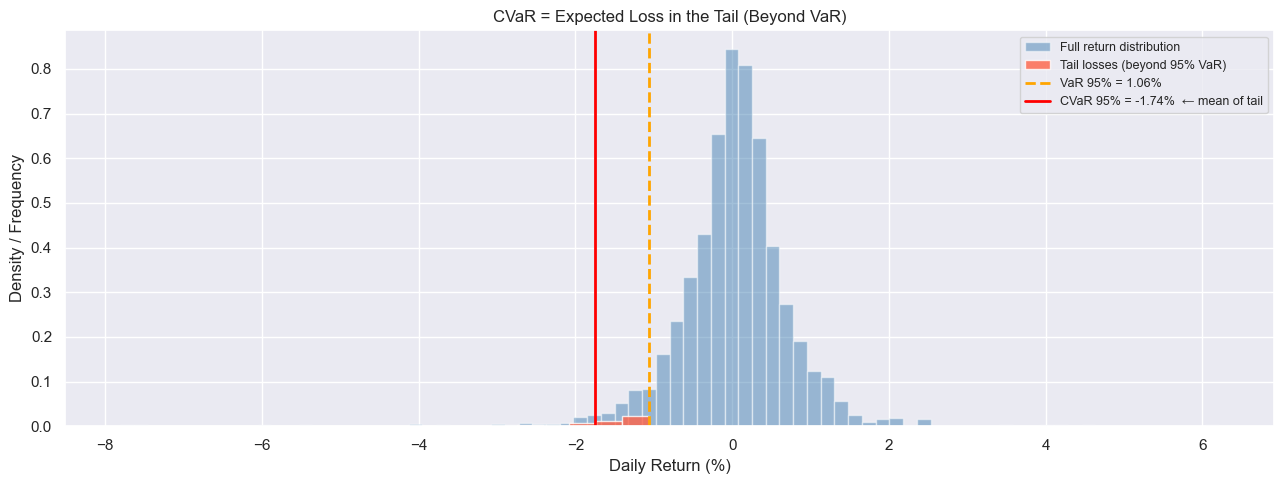

In [2]:
 #Visualise what CVaR actually measures on the return distribution

c     = 0.95
v     = hs_var[c]
tail  = returns[returns < -v]

plt.figure(figsize=(13, 5))
plt.hist(returns * 100, bins=80, density=True,
         color="steelblue", alpha=0.5, label="Full return distribution")
plt.hist(tail * 100, bins=20, density=False, weights=np.ones(len(tail)) / len(returns),
         color="tomato", alpha=0.8, label=f"Tail losses (beyond {int(c*100)}% VaR)")

plt.axvline(-v * 100, color="orange", linewidth=2, linestyle="--",
            label=f"VaR {int(c*100)}% = {v*100:.2f}%")
plt.axvline(tail.mean() * 100, color="red", linewidth=2, linestyle="-",
            label=f"CVaR {int(c*100)}% = {tail.mean()*100:.2f}%  ← mean of tail")

plt.title("CVaR = Expected Loss in the Tail (Beyond VaR)")
plt.xlabel("Daily Return (%)")
plt.ylabel("Density / Frequency")
plt.legend(fontsize=9)
plt.tight_layout()
plt.show()

# What to look for:
# The red vertical line (CVaR) is always to the LEFT of the orange (VaR)
# CVaR > VaR always — it's a worse number because it averages the worst cases


In [3]:
#  Simply take all returns worse than VaR and average them.
# No distribution assumption — purely empirical.
#
# CVaR_HS(c) = -mean(returns | returns < -VaR(c))

def historical_cvar(returns: np.ndarray, confidence: float) -> float:
    """
    Historical Simulation CVaR (Expected Shortfall).
    Returns CVaR as a POSITIVE number (loss convention).
    """
    var       = -np.percentile(returns, (1 - confidence) * 100)
    tail      = returns[returns < -var]
    cvar      = -tail.mean()
    return cvar


hs_cvar = {c: historical_cvar(returns, c) for c in conf_levels}

print("── Historical Simulation CVaR ───────────────────────────")
for c in conf_levels:
    n_tail = (returns < -hs_var[c]).sum()
    print(f"  {int(c*100)}% | VaR = {hs_var[c]*100:.4f}%"
          f"  | CVaR = {hs_cvar[c]*100:.4f}%"
          f"  | Tail obs = {n_tail}"
          f"  | CVaR/VaR ratio = {hs_cvar[c]/hs_var[c]:.3f}x")

── Historical Simulation CVaR ───────────────────────────
  95% | VaR = 1.0610%  | CVaR = 1.7442%  | Tail obs = 126  | CVaR/VaR ratio = 1.644x
  99% | VaR = 1.8886%  | CVaR = 3.1791%  | Tail obs = 26  | CVaR/VaR ratio = 1.683x


In [4]:
# Under normality, CVaR has a clean closed-form solution.
# No simulation needed — derived analytically from the normal distribution.
#
# CVaR_param(c) = -(μ + σ * [-φ(z_c) / (1 - c)])
#
# where:
#   φ(z_c) = standard normal PDF at the VaR quantile z_c
#   (1 - c) = tail probability
#   The term φ(z_c)/(1-c) is the "inverse Mills ratio"
#
# μ = 0 (conservative assumption, same as Phase 2)

def parametric_cvar(
    weights: np.ndarray,
    cov_matrix: pd.DataFrame,
    confidence: float,
    mu: float = 0.0,
) -> float:
    """
    Closed-form parametric CVaR under normality assumption.
    Returns CVaR as a POSITIVE number (loss convention).
    """
    cov_daily  = cov_matrix.values / 252
    port_sigma = np.sqrt(weights @ cov_daily @ weights)
    z          = norm.ppf(1 - confidence)        # e.g. -1.645 at 95%
    phi_z      = norm.pdf(z)                     # standard normal PDF at z
    cvar       = -(mu - port_sigma * phi_z / (1 - confidence))
    return cvar


param_cvar = {c: parametric_cvar(weights, cov_matrix, c) for c in conf_levels}

print("── Parametric CVaR (Closed Form) ────────────────────────")
for c in conf_levels:
    phi_z = norm.pdf(norm.ppf(1 - c))
    print(f"  {int(c*100)}% | VaR = {param_var[c]*100:.4f}%"
          f"  | CVaR = {param_cvar[c]*100:.4f}%"
          f"  | φ(z) = {phi_z:.4f}"
          f"  | CVaR/VaR ratio = {param_cvar[c]/param_var[c]:.3f}x")

── Parametric CVaR (Closed Form) ────────────────────────
  95% | VaR = 1.2132%  | CVaR = 1.5215%  | φ(z) = 0.1031  | CVaR/VaR ratio = 1.254x
  99% | VaR = 1.7159%  | CVaR = 1.9659%  | φ(z) = 0.0267  | CVaR/VaR ratio = 1.146x


In [5]:
# Same idea as HS CVaR but applied to simulated returns
# instead of historical returns.

def montecarlo_cvar(sim_returns: np.ndarray, confidence: float) -> float:
    """
    Monte Carlo CVaR from simulated portfolio returns.
    Returns CVaR as a POSITIVE number (loss convention).
    """
    var  = -np.percentile(sim_returns, (1 - confidence) * 100)
    tail = sim_returns[sim_returns < -var]
    return -tail.mean()


mc_cvar = {c: montecarlo_cvar(sim_portfolio_returns, c) for c in conf_levels}

print("── Monte Carlo CVaR ─────────────────────────────────────")
for c in conf_levels:
    n_tail = (sim_portfolio_returns < -mc_var[c]).sum()
    print(f"  {int(c*100)}% | VaR = {mc_var[c]*100:.4f}%"
          f"  | CVaR = {mc_cvar[c]*100:.4f}%"
          f"  | Tail obs = {n_tail}"
          f"  | CVaR/VaR ratio = {mc_cvar[c]/mc_var[c]:.3f}x")

── Monte Carlo CVaR ─────────────────────────────────────
  95% | VaR = 1.1891%  | CVaR = 1.5127%  | Tail obs = 500  | CVaR/VaR ratio = 1.272x
  99% | VaR = 1.7007%  | CVaR = 1.9787%  | Tail obs = 100  | CVaR/VaR ratio = 1.163x


In [6]:
rows = []
for c in conf_levels:
    rows.append({
        "Confidence":         f"{int(c*100)}%",
        "HS VaR (%)":         round(hs_var[c]    * 100, 4),
        "HS CVaR (%)":        round(hs_cvar[c]   * 100, 4),
        "Param VaR (%)":      round(param_var[c] * 100, 4),
        "Param CVaR (%)":     round(param_cvar[c]* 100, 4),
        "MC VaR (%)":         round(mc_var[c]    * 100, 4),
        "MC CVaR (%)":        round(mc_cvar[c]   * 100, 4),
    })

comparison = pd.DataFrame(rows).set_index("Confidence")
print("── Full VaR vs CVaR Comparison ──────────────────────────")
comparison

── Full VaR vs CVaR Comparison ──────────────────────────


,HS VaR (%),HS CVaR (%),Param VaR (%),Param CVaR (%),MC VaR (%),MC CVaR (%)
Confidence,,,,,,
95%,1.0610,1.7442,1.2132,1.5215,1.1891,1.5127
99%,1.8886,3.1791,1.7159,1.9659,1.7007,1.9787


In [7]:
PORTFOLIO_VALUE = 1_000_000

dollar = pd.DataFrame({
    "HS VaR ($)":     {f"{int(c*100)}%": hs_var[c]     * PORTFOLIO_VALUE for c in conf_levels},
    "HS CVaR ($)":    {f"{int(c*100)}%": hs_cvar[c]    * PORTFOLIO_VALUE for c in conf_levels},
    "Param VaR ($)":  {f"{int(c*100)}%": param_var[c]  * PORTFOLIO_VALUE for c in conf_levels},
    "Param CVaR ($)": {f"{int(c*100)}%": param_cvar[c] * PORTFOLIO_VALUE for c in conf_levels},
    "MC VaR ($)":     {f"{int(c*100)}%": mc_var[c]     * PORTFOLIO_VALUE for c in conf_levels},
    "MC CVaR ($)":    {f"{int(c*100)}%": mc_cvar[c]    * PORTFOLIO_VALUE for c in conf_levels},
})

print(f"── Dollar Risk (Portfolio = ${PORTFOLIO_VALUE:,}) ───────────────")
print(dollar.map(lambda x: f"${x:,.0f}").to_string())

── Dollar Risk (Portfolio = $1,000,000) ───────────────
    HS VaR ($) HS CVaR ($) Param VaR ($) Param CVaR ($) MC VaR ($) MC CVaR ($)
95%    $10,610     $17,442       $12,132        $15,215    $11,891     $15,127
99%    $18,886     $31,791       $17,159        $19,659    $17,007     $19,787


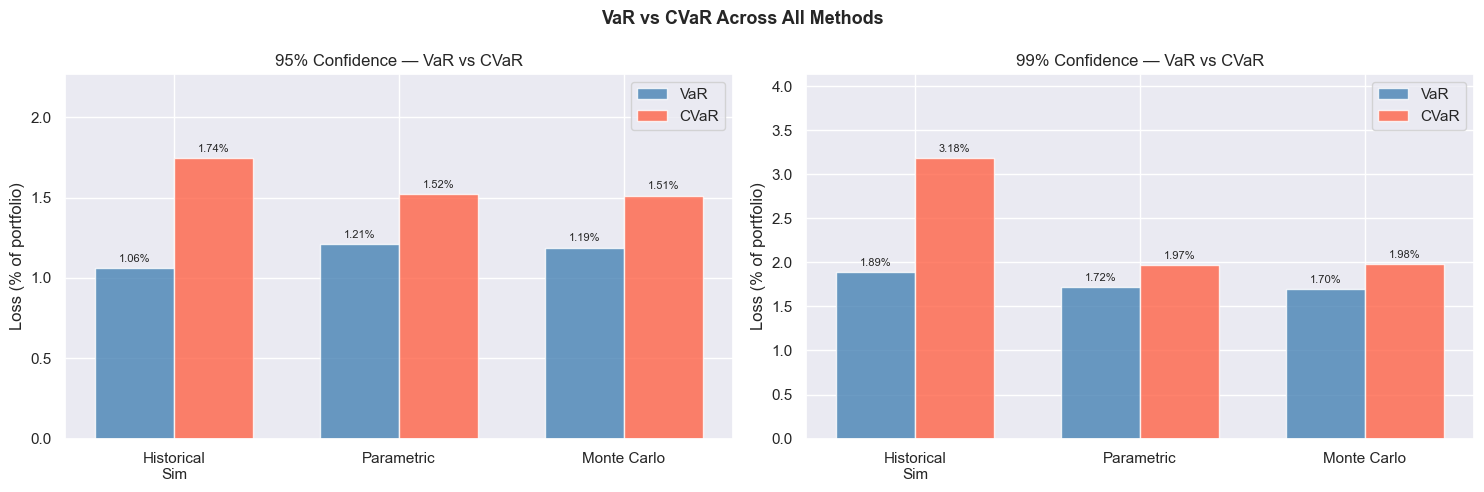

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
methods   = ["Historical\nSim", "Parametric", "Monte Carlo"]
var_vals  = [hs_var,    param_var,    mc_var]
cvar_vals = [hs_cvar,   param_cvar,   mc_cvar]
x         = np.arange(len(methods))
width     = 0.35

for ax, c in zip(axes, conf_levels):
    vars_  = [v[c] * 100 for v in var_vals]
    cvars_ = [v[c] * 100 for v in cvar_vals]

    b1 = ax.bar(x - width/2, vars_,  width, label="VaR",  color="steelblue", alpha=0.8)
    b2 = ax.bar(x + width/2, cvars_, width, label="CVaR", color="tomato",    alpha=0.8)
    ax.bar_label(b1, fmt="%.2f%%", padding=3, fontsize=8)
    ax.bar_label(b2, fmt="%.2f%%", padding=3, fontsize=8)

    ax.set_title(f"{int(c*100)}% Confidence — VaR vs CVaR")
    ax.set_xticks(x)
    ax.set_xticklabels(methods)
    ax.set_ylabel("Loss (% of portfolio)")
    ax.set_ylim(0, max(cvars_) * 1.3)
    ax.legend()

plt.suptitle("VaR vs CVaR Across All Methods", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

# What to look for:
# CVaR (red) always exceeds VaR (blue) — by definition
# The CVaR/VaR gap is larger at 99% than 95% — tail gets fatter further out
# HS CVaR > Parametric CVaR at 99% → empirical tail is fatter than normal assumes

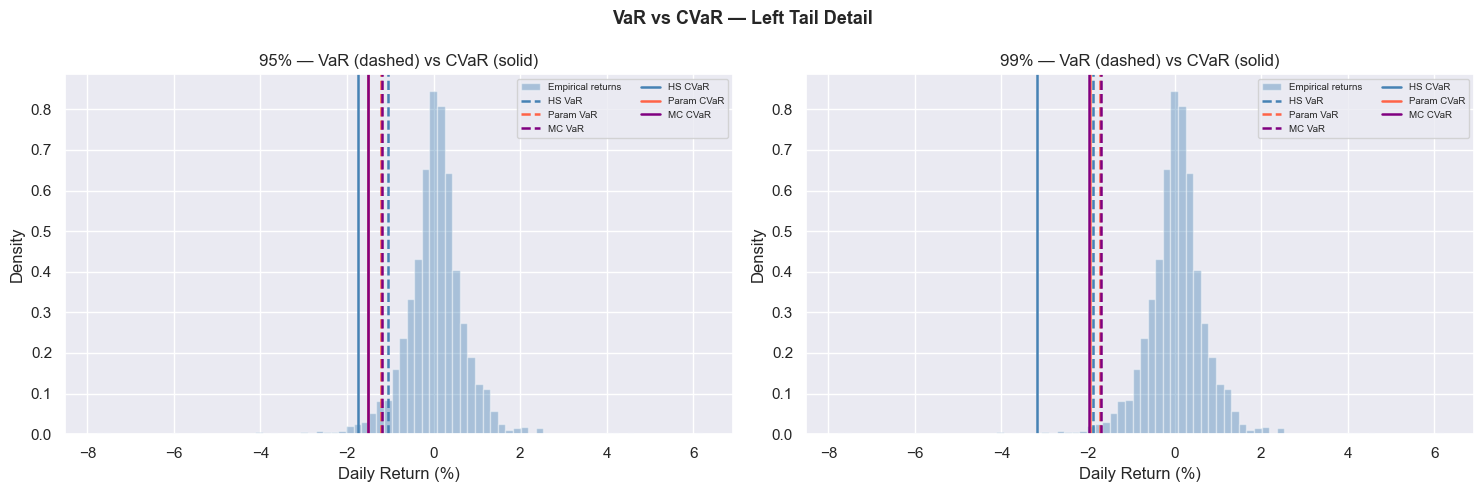

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

for ax, c in zip(axes, conf_levels):
    ax.hist(returns * 100, bins=80, density=True,
            color="steelblue", alpha=0.4, label="Empirical returns")

    # VaR lines
    ax.axvline(-hs_var[c]    * 100, color="steelblue", lw=1.8, ls="--", label=f"HS VaR")
    ax.axvline(-param_var[c] * 100, color="tomato",    lw=1.8, ls="--", label=f"Param VaR")
    ax.axvline(-mc_var[c]    * 100, color="purple",    lw=1.8, ls="--", label=f"MC VaR")

    # CVaR lines
    ax.axvline(-hs_cvar[c]    * 100, color="steelblue", lw=1.8, ls="-", label=f"HS CVaR")
    ax.axvline(-param_cvar[c] * 100, color="tomato",    lw=1.8, ls="-", label=f"Param CVaR")
    ax.axvline(-mc_cvar[c]    * 100, color="purple",    lw=1.8, ls="-", label=f"MC CVaR")

    ax.set_title(f"{int(c*100)}% — VaR (dashed) vs CVaR (solid)")
    ax.set_xlabel("Daily Return (%)")
    ax.set_ylabel("Density")
    ax.legend(fontsize=7, ncol=2)

plt.suptitle("VaR vs CVaR — Left Tail Detail", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

In [10]:
# The CVaR/VaR ratio tells you how "heavy" your tail is.
# Normal distribution → ratio is fixed (~1.26 at 95%, ~1.16 at 99%)
# If HS ratio > parametric ratio → fatter tails than normal assumes

print("── CVaR / VaR Ratios ────────────────────────────────────")
print(f"{'':25s} {'95%':>10s}  {'99%':>10s}")
print(f"{'Normal (theoretical)':25s} {'~1.26':>10s}  {'~1.16':>10s}")
for name, var_d, cvar_d in [
    ("Historical Sim",  hs_var,    hs_cvar),
    ("Parametric",      param_var, param_cvar),
    ("Monte Carlo",     mc_var,    mc_cvar),
]:
    ratios = {c: cvar_d[c] / var_d[c] for c in conf_levels}
    print(f"{name:25s} {ratios[0.95]:>10.4f}  {ratios[0.99]:>10.4f}")

# If HS ratio >> 1.26 at 95% → your portfolio has significant fat tails
# This motivates using CVaR over VaR for capital allocation

── CVaR / VaR Ratios ────────────────────────────────────
                                 95%         99%
Normal (theoretical)           ~1.26       ~1.16
Historical Sim                1.6439      1.6833
Parametric                    1.2540      1.1457
Monte Carlo                   1.2721      1.1635


In [11]:
cvar_results = {
    "hs_cvar":    hs_cvar,
    "param_cvar": param_cvar,
    "mc_cvar":    mc_cvar,
}

data.update(cvar_results)

with open("portfolio_data.pkl", "wb") as f:
    pickle.dump(data, f)

print("portfolio_data.pkl updated with Phase 3 CVaR results.")
print("\nAll keys now in portfolio_data:")
for k in data.keys():
    print(f"  {k}")

portfolio_data.pkl updated with Phase 3 CVaR results.

All keys now in portfolio_data:
  prices
  log_returns
  portfolio_returns
  weights
  tickers
  stats
  cov_matrix
  corr_matrix
  lookback
  conf_levels
  hs_var
  param_var
  mc_var
  sim_portfolio_returns
  comparison_table
  hs_cvar
  param_cvar
  mc_cvar
